# 01 — Customer Segmentation with Clustering

This notebook builds a customer segmentation workflow.

The modelling goal is to discover useful behavioural groups without using predefined segment labels.


In [1]:
import sys
from itertools import combinations
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import DBSCAN, AgglomerativeClustering, KMeans
from sklearn.datasets import make_blobs, make_moons
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

sys.path.append(str(Path.cwd() / "src"))

from unsup_lab.data import make_customer_segmentation_data
from unsup_lab.evaluation import evaluate_clustering, evaluate_k_range
from unsup_lab.plotting import plot_embedding
from unsup_lab.preprocessing import scale_features
from unsup_lab.reporting import cluster_profile

## Generate customer behaviour data

In [2]:
dataset = make_customer_segmentation_data(n_customers=2_000, random_state=42)
features = dataset.features

features.head()

,recency_days,purchase_frequency,avg_order_value,discount_ratio,email_engagement,product_diversity
0,1.000000,40.540314,5.000000,0.317091,0.683116,0.676432
1,6.876079,1.000000,29.332878,0.221249,0.258808,0.183839
2,109.291088,4.847708,134.117057,0.191133,0.355464,0.300469
3,22.572693,29.298219,46.476565,0.188546,0.747382,0.817508
4,21.909348,24.853125,176.549213,0.122484,0.799835,0.661402


The hidden labels are kept only for later sanity checks. They are not used by the clustering models.


In [3]:
x_scaled = scale_features(features, method="standard")
x_scaled.describe().round(2)

,recency_days,purchase_frequency,avg_order_value,discount_ratio,email_engagement,product_diversity
count,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00
mean,-0.00,0.00,-0.00,0.00,-0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00,1.00
min,-0.92,-1.29,-1.29,-1.53,-2.37,-2.08
25%,-0.64,-0.87,-0.80,-0.74,-0.89,-0.91
50%,-0.37,-0.18,-0.24,-0.26,0.23,0.28
75%,0.06,0.78,0.63,0.43,0.80,0.79
max,2.64,2.58,2.96,2.64,1.86,2.10


## Compare different clustering assumptions

In [4]:
k_results = evaluate_k_range(
    x_scaled,
    estimator_factory=lambda k: KMeans(n_clusters=k, n_init=20, random_state=42),
    k_values=[2, 3, 4, 5, 6, 7, 8],
)

k_results

,k,n_clusters,silhouette,davies_bouldin,calinski_harabasz
0,2,2,0.405381,1.142318,1341.290177
1,3,3,0.448927,0.957036,1459.469089
2,4,4,0.530253,0.727970,1957.062211
3,5,5,0.619262,0.558631,3641.868539
4,6,6,0.513274,1.115936,3043.412742
5,7,7,0.416025,1.445764,2639.701362
6,8,8,0.318132,1.749631,2351.420644


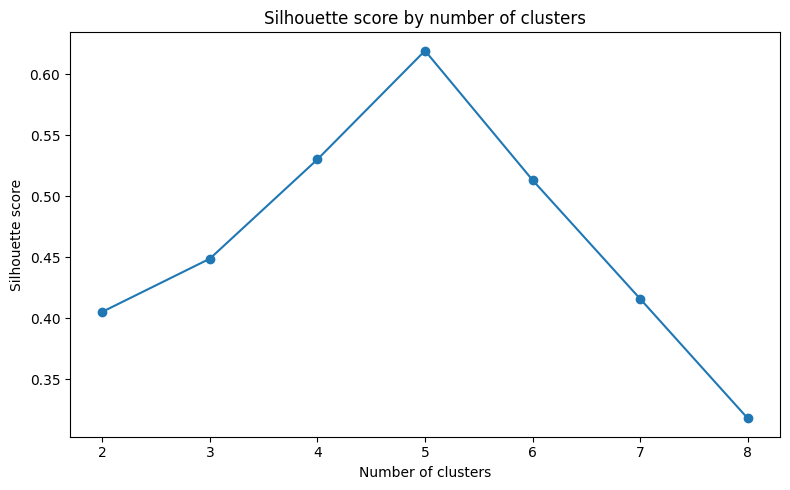

In [5]:
plt.figure(figsize=(8, 5))
plt.plot(k_results["k"], k_results["silhouette"], marker="o")
plt.title("Silhouette score by number of clusters")
plt.xlabel("Number of clusters")
plt.ylabel("Silhouette score")
plt.tight_layout()
plt.show()

## Fit selected models

In [6]:
models = {
    "kmeans": KMeans(n_clusters=5, n_init=20, random_state=42),
    "gmm": GaussianMixture(n_components=5, random_state=42),
    "agglomerative": AgglomerativeClustering(n_clusters=5),
    "dbscan": DBSCAN(eps=1.2, min_samples=20),
}

labels_by_model = {}
for name, model in models.items():
    labels_by_model[name] = model.fit_predict(x_scaled)
    print(name, evaluate_clustering(x_scaled, labels_by_model[name]))

# Identical metrics are suspicious: are these the same partition, or different
# partitions that happen to score alike? Compare the labellings to each other.
print("\npairwise agreement between the partitions (adjusted Rand index):")
for left, right in combinations(labels_by_model, 2):
    ari = adjusted_rand_score(labels_by_model[left], labels_by_model[right])
    print(f"  {left:14s} vs {right:14s} {ari:.3f}")

kmeans ClusteringMetrics(n_clusters=5, silhouette=0.619261852604857, davies_bouldin=0.558630864494486, calinski_harabasz=3641.8685387047353)


gmm ClusteringMetrics(n_clusters=5, silhouette=0.619261852604857, davies_bouldin=0.558630864494486, calinski_harabasz=3641.8685387047353)


agglomerative ClusteringMetrics(n_clusters=5, silhouette=0.619261852604857, davies_bouldin=0.558630864494486, calinski_harabasz=3641.868538704735)
dbscan ClusteringMetrics(n_clusters=2, silhouette=0.307195012089844, davies_bouldin=0.9726530920162175, calinski_harabasz=609.6774471481151)

pairwise agreement between the partitions (adjusted Rand index):
  kmeans         vs gmm            1.000
  kmeans         vs agglomerative  1.000
  kmeans         vs dbscan         0.178
  gmm            vs agglomerative  1.000
  gmm            vs dbscan         0.178
  agglomerative  vs dbscan         0.178


### Three methods, one partition

The three parametric methods do not merely score alike — they return **the same partition**, ARI 1.000, down to identical cluster sizes. DBSCAN is the only one that differs, and it differs by failing: a single `eps` collapses the five segments into two clusters plus one noise point.

It is tempting to read the agreement as "the choice of algorithm does not matter much". That reading is wrong, and the reason is worth stating plainly: **this generator plants five compact, well-separated, roughly spherical blobs**, which is precisely the regime where a centroid, a full-covariance Gaussian and Ward linkage all describe the same thing. Agreement here is a property of the *data*, not evidence about the *methods*. A comparison run only on data this convenient cannot distinguish them, so it cannot justify the choice either.

To see what each assumption actually buys, the data has to stop being convenient.

## Where the assumptions bite

Four small 2D datasets, each built to break one assumption, with the generating labels kept aside for *offline* scoring only:

| Dataset | What it tests |
| --- | --- |
| spherical blobs | the control - the customer data's regime |
| elongated blobs | clusters sheared into ellipses: is a centroid enough? |
| non-convex moons | interleaved crescents: is a cluster a *blob* at all? |
| mixed density | a tight core beside a diffuse neighbour: can one density rule serve both? |

Five candidates run on all four, configured identically everywhere - including two agglomerative linkages, because the linkage is itself an assumption. DBSCAN's `eps` cannot be left fixed across datasets on different scales, so it is set by one transparent rule applied to every dataset: the 85th percentile of the distance to each point's 10th-nearest neighbour. That rule uses no labels, which is the point; it is also the honest source of DBSCAN's weakest results.

In [7]:
def diagnostic_shapes() -> list[tuple[str, np.ndarray, np.ndarray]]:
    """Build four 2D datasets, each breaking a different clustering assumption."""
    rng = np.random.default_rng(3)
    scale = StandardScaler().fit_transform

    blob_x, blob_y = make_blobs(n_samples=450, centers=3, cluster_std=0.7, random_state=0)

    long_x, long_y = make_blobs(n_samples=450, centers=3, cluster_std=0.5, random_state=0)
    long_x = long_x @ np.array([[0.5, -0.75], [-0.35, 0.9]])  # shear blobs into ellipses

    moon_x, moon_y = make_moons(n_samples=450, noise=0.06, random_state=0)

    core = rng.normal([0.0, 0.0], 0.12, size=(260, 2))  # tight cluster
    halo = rng.normal([1.8, 0.0], 0.90, size=(190, 2))  # diffuse neighbour

    return [
        ("spherical blobs", scale(blob_x), blob_y),
        ("elongated blobs", scale(long_x), long_y),
        ("non-convex moons", scale(moon_x), moon_y),
        ("mixed density", scale(np.vstack([core, halo])), np.repeat([0, 1], [260, 190])),
    ]


def knn_eps(data: np.ndarray, min_samples: int = 10, quantile: float = 0.85) -> float:
    """Set DBSCAN's eps from the k-nearest-neighbour distance distribution."""
    distances, _ = NearestNeighbors(n_neighbors=min_samples).fit(data).kneighbors(data)
    return float(np.quantile(distances[:, -1], quantile))


def candidates(data: np.ndarray, k: int) -> dict[str, object]:
    """The five candidate clusterings, configured the same way for every dataset."""
    return {
        "KMeans": KMeans(n_clusters=k, n_init=20, random_state=0),
        "GMM (full)": GaussianMixture(n_components=k, random_state=0),
        "Agglomerative (ward)": AgglomerativeClustering(n_clusters=k),
        "Agglomerative (single)": AgglomerativeClustering(n_clusters=k, linkage="single"),
        "DBSCAN": DBSCAN(eps=knn_eps(data), min_samples=10),
    }


shapes = diagnostic_shapes()
predictions: dict[tuple[str, str], np.ndarray] = {}
rows = []
for shape_name, x, y in shapes:
    row = {"dataset": shape_name}
    for method, model in candidates(x, len(np.unique(y))).items():
        predictions[(shape_name, method)] = model.fit_predict(x)
        row[method] = adjusted_rand_score(y, predictions[(shape_name, method)])
    rows.append(row)

scores = pd.DataFrame(rows).set_index("dataset")
method_names = list(scores.columns)
scores.round(2)

,KMeans,GMM (full),Agglomerative (ward),Agglomerative (single),DBSCAN
dataset,,,,,
spherical blobs,0.98,0.98,0.92,0.00,0.93
elongated blobs,0.71,1.00,0.77,0.57,0.90
non-convex moons,0.49,0.51,0.65,1.00,0.96
mixed density,0.65,0.97,0.90,0.00,0.06


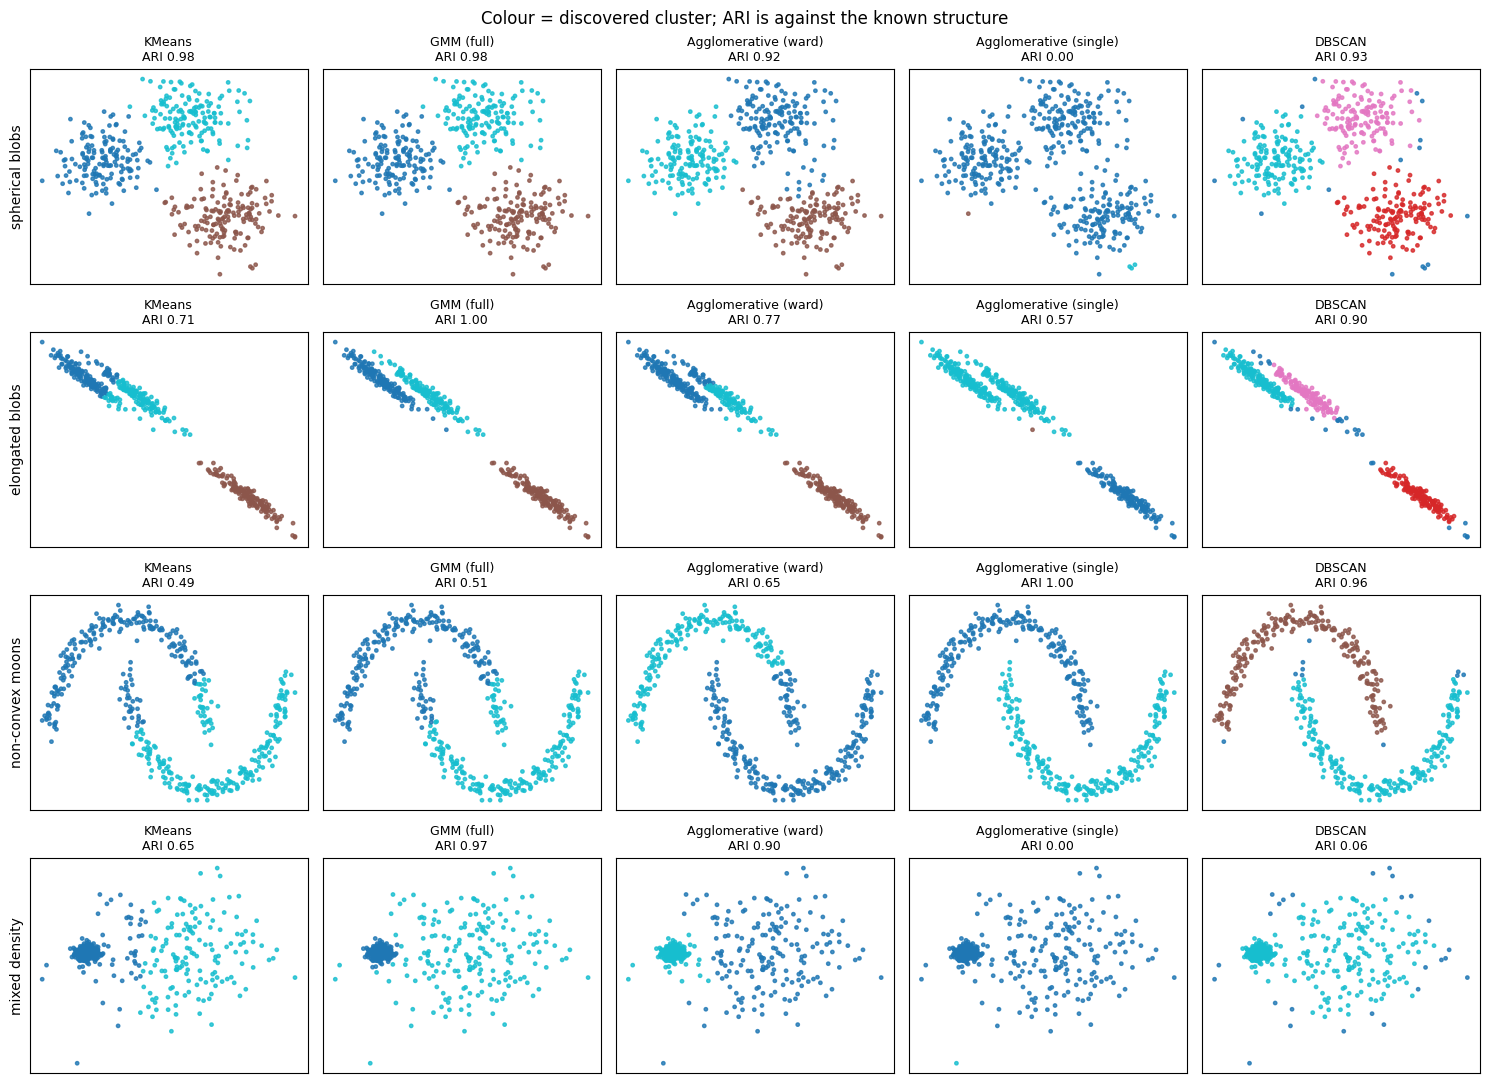

In [8]:
fig, axes = plt.subplots(len(shapes), len(method_names), figsize=(15, 11))
for row_index, (shape_name, x, y) in enumerate(shapes):
    for col_index, method in enumerate(method_names):
        ax = axes[row_index, col_index]
        labels = predictions[(shape_name, method)]
        ax.scatter(x[:, 0], x[:, 1], c=labels, cmap="tab10", s=6, alpha=0.8)
        ax.set_title(f"{method}\nARI {adjusted_rand_score(y, labels):.2f}", fontsize=9)
        ax.set_xticks([])
        ax.set_yticks([])
    axes[row_index, 0].set_ylabel(shape_name, fontsize=10)

fig.suptitle("Colour = discovered cluster; ARI is against the known structure", fontsize=12)
fig.tight_layout()
plt.show()

### Reading the table

Every method wins somewhere and fails somewhere, which is the whole argument:

- **KMeans** is the best on the control and the worst of the five on the moons (0.49). It is not that it does badly there - it is that a centroid *cannot* express a crescent, so it splits each moon down the middle. The failure is structural, not a tuning problem.
- **The Gaussian mixture** buys its way out of the elongated case (1.00 against KMeans' 0.71): a full covariance matrix is exactly the freedom to stretch and rotate a cluster. It also leads on mixed density (0.97), because a Gaussian is perfectly happy to be wide.
- **Ward linkage** shares KMeans' variance-minimising bias, which is why the two land in the same place on the control and on the customer data. They are not interchangeable, though: Ward keeps the diffuse cluster intact where KMeans fractures it (0.90 against 0.65).
- **Single linkage** is the sharpest illustration that the assumption, not the algorithm family, is what matters. It is the only perfect score on the moons (1.00), because it asks only that a cluster be connected - and it is the worst method on the other three (0.00 on the blobs and on mixed density, 0.57 on the elongated blobs), because that same permissiveness lets a single bridging point chain two clusters into one.
- **DBSCAN** is the other winner on the moons (0.96) and the clear loser on mixed density (0.06). One `eps` cannot be simultaneously tight enough to keep the dense core intact and loose enough to hold the diffuse halo together, so it dissolves the halo into noise.

The practical consequence for the segmentation above: KMeans, the mixture and Ward agreed **because the customer features form compact spherical segments**, not because the choice was unimportant. Had the segments been elongated - which real RFM-style features often are, since spend and frequency correlate - the same three methods would have diverged, and the silhouette would not have told us which to believe.

## Visualise one selected solution

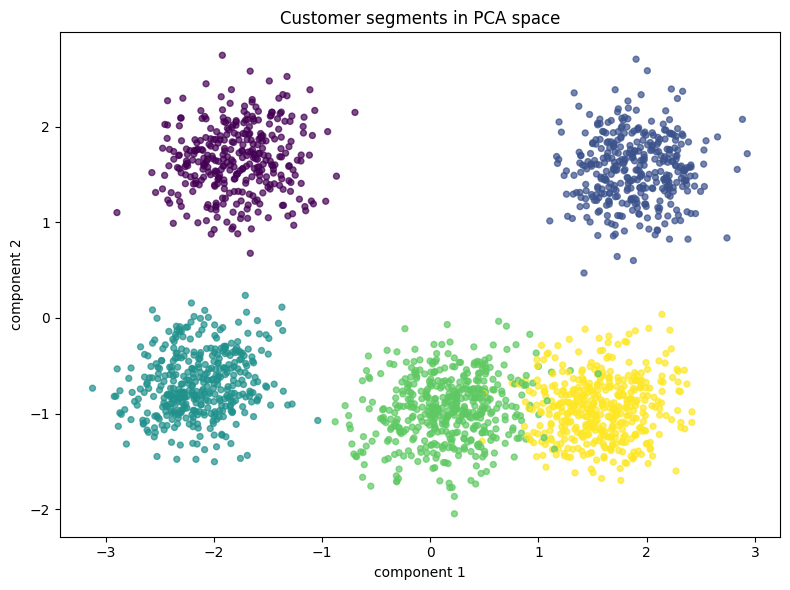

In [9]:
pca = PCA(n_components=2, random_state=42)
embedding = pca.fit_transform(x_scaled)
selected_labels = labels_by_model["kmeans"]

plot_embedding(embedding, selected_labels, title="Customer segments in PCA space")

## Segment profiling

In [10]:
profile = cluster_profile(features, selected_labels)
profile.round(2)

,recency_days,purchase_frequency,avg_order_value,discount_ratio,email_engagement,product_diversity,cluster_size
cluster,,,,,,,
0,110.01,7.57,113.66,0.20,0.38,0.29,335
1,18.30,23.82,187.85,0.12,0.82,0.75,369
2,12.05,3.41,35.73,0.28,0.21,0.17,399
3,33.32,13.85,73.09,0.72,0.62,0.58,467
4,10.29,36.05,30.50,0.33,0.73,0.66,430


## Interpretation

The output should be converted into business-readable segment cards.

Examples:

- High-value loyal customers.
- Discount-sensitive customers.
- Low-engagement new customers.
- Frequent low-value buyers.
- At-risk previous buyers.

These names should be validated with domain experts and operational data.


## Limitations

Clusters are not natural laws. They depend on feature selection, scaling, algorithm assumptions, and the chosen number of clusters. They should guide exploration and decision-making, not be treated as causal evidence.
